# Best Run Error Analysis



In [59]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import ConfusionMatrixDisplay

# NOTE: Keep the colors simple so the exported figures drop into the LaTeX report without extra cleanup.
PALETTE = {
    "navy": "#295c8a",
    "teal": "#2a9d8f",
    "gold": "#e9c46a",
    "coral": "#e76f51",
    "rose": "#c8556d",
    "plum": "#7b6dba",
}

# NOTE: These two colormaps are just for the confusion-matrix figure.
CONFUSION_COUNT_CMAP = LinearSegmentedColormap.from_list(
    "flight_delay_counts", ["#f7fbff", "#c6dbef", PALETTE["navy"]]
)
CONFUSION_RATE_CMAP = LinearSegmentedColormap.from_list(
    "flight_delay_rates", ["#fff5eb", "#f4a261", PALETTE["coral"]]
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# NOTE: Fixed filenames mean I do not have to keep updating image paths in the report.
FIGURE_PATHS = {
    "scorecard": FIGURES_DIR / "best_run_error_scorecard.png",
    "confusion": FIGURES_DIR / "best_run_confusion_matrices.png",
    "confusion_pairs": FIGURES_DIR / "best_run_confusion_pairs.png",
    "error_slices": FIGURES_DIR / "best_run_error_slices.png",
}

selection_path = ROOT / "reports" / "evaluation" / "batch_runs" / "final-best-model.json"
selection = json.loads(selection_path.read_text(encoding="utf-8"))
best = selection["best_model"]
evaluation_path = Path(best["evaluation_report_path"])
evaluation = json.loads(evaluation_path.read_text(encoding="utf-8"))

X_test = pd.read_csv(ROOT / "data" / "processed" / "test_features.csv")
y_test = pd.read_csv(ROOT / "data" / "processed" / "test_labels.csv")["DELAY_CATEGORY"]
preds = pd.read_csv(Path(evaluation["artifacts"]["predictions_path"]))

# NOTE: These files have to stay in the same row order because the prediction export has no row IDs.
analysis_df = X_test.copy()
analysis_df["y_true"] = y_test.to_numpy()
analysis_df["y_pred"] = preds["y_pred"].to_numpy()
analysis_df["is_error"] = analysis_df["y_true"] != analysis_df["y_pred"]
# NOTE: qcut can choke on repeated bin edges, so duplicates="drop" keeps the split from blowing up.
analysis_df["distance_band"] = pd.qcut(analysis_df["DISTANCE"], q=4, duplicates="drop")
analysis_df["scheduled_time_band"] = pd.qcut(analysis_df["SCHEDULED_TIME"], q=4, duplicates="drop")

run_summary = pd.Series(
    {
        "run_name": best["run_name"],
        "model_mode": best["model_mode"],
        "balanced_accuracy": best["core_metrics"]["balanced_accuracy"],
        "macro_f1": best["core_metrics"]["macro_f1"],
        "avg_cost": best["cost_metrics"]["average_misclassification_cost"],
        "holdout_rows": len(analysis_df),
    }
)
run_summary

run_name             final-hist_gradient_boosting
model_mode                 hist_gradient_boosting
balanced_accuracy                         0.45911
macro_f1                                 0.330745
avg_cost                                 1.001855
holdout_rows                                21290
dtype: object

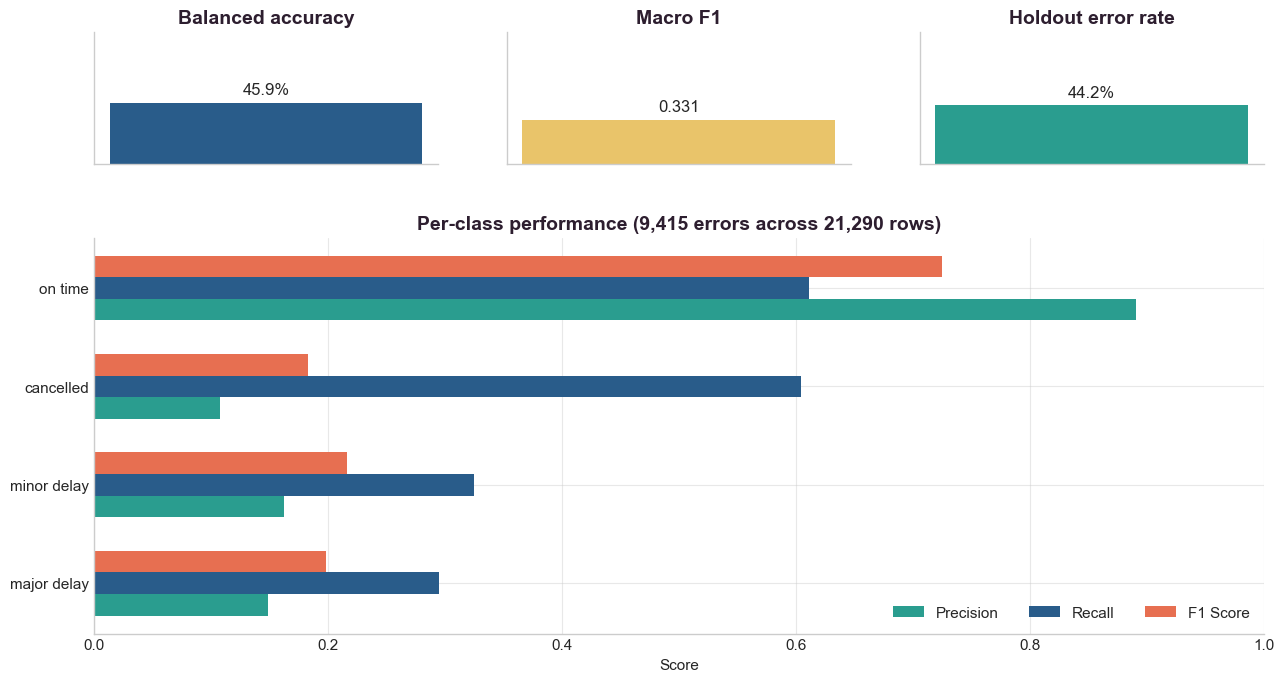

In [60]:
per_class = pd.DataFrame(evaluation["per_class"]).T.rename_axis("class").sort_values("recall")
overall_error_rate = analysis_df["is_error"].mean()
overall_error_count = int(analysis_df["is_error"].sum())
metric_colors = [PALETTE["navy"], PALETTE["gold"], PALETTE["teal"]]

fig = plt.figure(figsize=(13, 7))
# NOTE: The top row is for the headline numbers. The bottom row is the class-by-class view.
grid = fig.add_gridspec(2, 3, height_ratios=[1.0, 3.0], hspace=0.28)

metric_specs = [
    ("Balanced accuracy", best["core_metrics"]["balanced_accuracy"], metric_colors[0], "{:.1%}"),
    ("Macro F1", best["core_metrics"]["macro_f1"], metric_colors[1], "{:.3f}"),
    ("Holdout error rate", overall_error_rate, metric_colors[2], "{:.1%}"),
]

for idx, (label, value, color, fmt) in enumerate(metric_specs):
    ax = fig.add_subplot(grid[0, idx])
    ax.bar([label], [value], color=color, width=0.55)
    ax.set_ylim(0, 1)
    ax.set_title(label)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.text(0, value + 0.04, fmt.format(value), ha="center", va="bottom", fontsize=12)

ax = fig.add_subplot(grid[1, :])
classes = per_class.index.tolist()
y_pos = np.arange(len(classes))
# NOTE: The slight vertical offsets keep precision, recall, and F1 on one class row without overlapping.
bar_height = 0.22
for offset, metric, color in zip(
    [-bar_height, 0, bar_height],
    ["precision", "recall", "f1_score"],
    [PALETTE["teal"], PALETTE["navy"], PALETTE["coral"]],
):
    values = per_class[metric].to_numpy()
    ax.barh(y_pos + offset, values, height=bar_height, label=metric.replace("_", " ").title(), color=color)

ax.set_yticks(y_pos)
ax.set_yticklabels([label.replace("_", " ") for label in classes])
ax.set_xlim(0, 1.0)
ax.set_xlabel("Score")
ax.set_title(f"Per-class performance ({overall_error_count:,} errors across {len(analysis_df):,} rows)")
ax.legend(frameon=False, ncol=3, loc="lower right")
fig.subplots_adjust(top=0.94, bottom=0.08, left=0.08, right=0.98)
# NOTE: Save at 300 dpi with a tight box so the PNG is ready to paste into the report.
fig.savefig(FIGURE_PATHS["scorecard"], dpi=300, bbox_inches="tight")

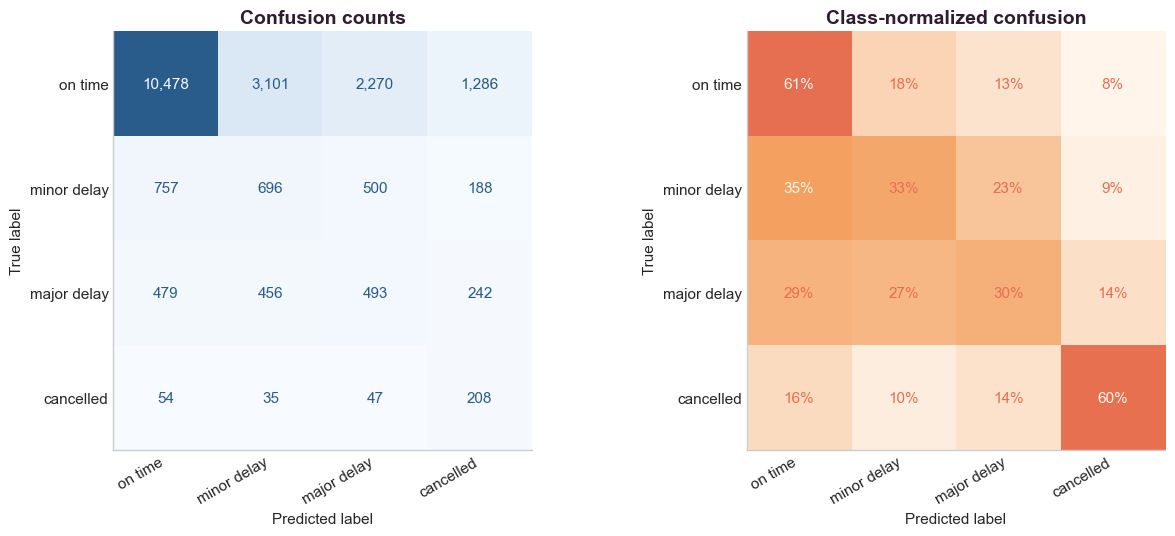

In [61]:
labels = ["on_time", "minor_delay", "major_delay", "cancelled"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# NOTE: The left panel keeps raw counts so it is obvious which mistakes happen most often.
ConfusionMatrixDisplay.from_predictions(
    analysis_df["y_true"],
    analysis_df["y_pred"],
    labels=labels,
    normalize=None,
    cmap=CONFUSION_COUNT_CMAP,
    values_format=",.0f",
    colorbar=False,
    ax=axes[0],
)
# NOTE: Turn the seaborn grid off here, otherwise it sits on top of the heatmap and looks messy.
axes[0].grid(False)
axes[0].set_title("Confusion counts")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xticklabels([label.replace("_", " ") for label in labels], ha="right")
axes[0].set_yticklabels([label.replace("_", " ") for label in labels])

# NOTE: The right panel is normalized by the true class, which makes the recall misses easier to spot.
ConfusionMatrixDisplay.from_predictions(
    analysis_df["y_true"],
    analysis_df["y_pred"],
    labels=labels,
    normalize="true",
    cmap=CONFUSION_RATE_CMAP,
    values_format=".0%",
    colorbar=False,
    ax=axes[1],
)
axes[1].grid(False)
axes[1].set_title("Class-normalized confusion")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xticklabels([label.replace("_", " ") for label in labels], ha="right")
axes[1].set_yticklabels([label.replace("_", " ") for label in labels])

plt.tight_layout()
fig.savefig(FIGURE_PATHS["confusion"], dpi=300, bbox_inches="tight")

,pair,count,share_of_errors
0,on_time -> minor_delay,3101,32.9%
1,on_time -> major_delay,2270,24.1%
2,on_time -> cancelled,1286,13.7%
3,minor_delay -> on_time,757,8.0%
4,minor_delay -> major_delay,500,5.3%
5,major_delay -> on_time,479,5.1%
6,major_delay -> minor_delay,456,4.8%
7,major_delay -> cancelled,242,2.6%


Best run: final-hist_gradient_boosting (hist_gradient_boosting)
Weakest recall class: major_delay (29.5%)
Most common confusion: on_time -> minor_delay (32.9% of all errors)
Worst large slice: dest_weather_code=71.0 with 81.7% error across 191 rows


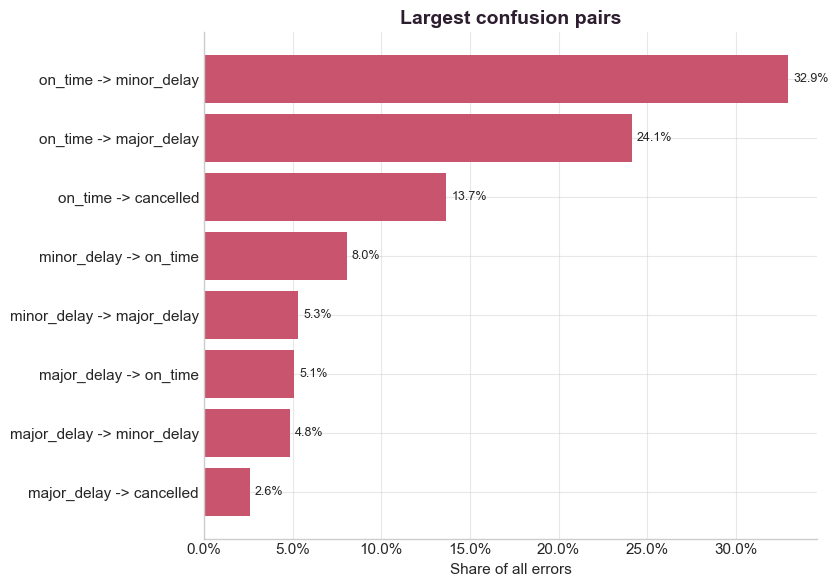

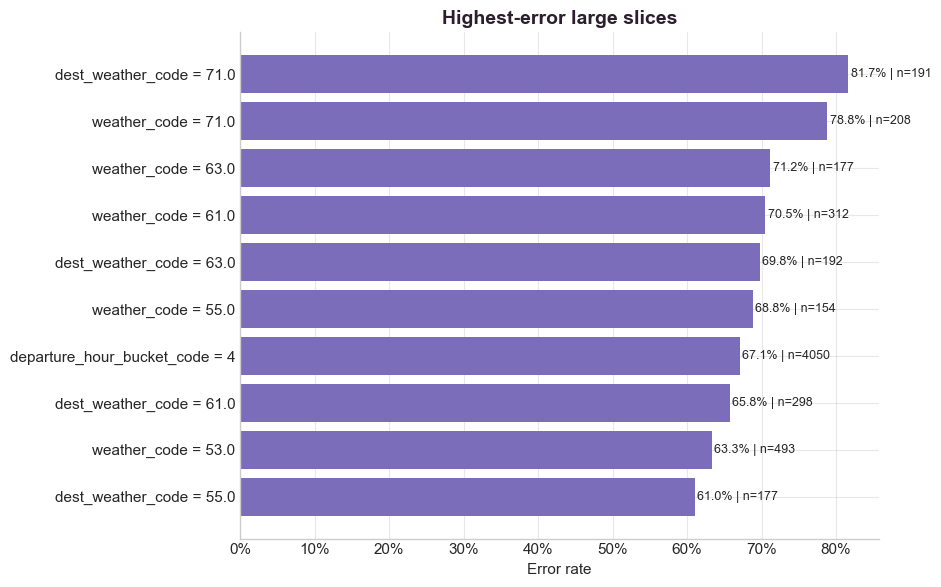

In [62]:
confusions = (
    analysis_df.loc[analysis_df["is_error"], ["y_true", "y_pred"]]
    .value_counts()
    .rename("count")
    .reset_index()
)
confusions["share_of_errors"] = confusions["count"] / confusions["count"].sum()
confusions["pair"] = confusions["y_true"] + " -> " + confusions["y_pred"]

display(
    confusions.head(8)[["pair", "count", "share_of_errors"]].style.format(
        {"share_of_errors": "{:.1%}"}
    )
)

slice_cols = [
    "departure_hour_bucket_code",
    "DAY_OF_WEEK",
    "is_weekend",
    "weather_code",
    "dest_weather_code",
    "distance_band",
    "scheduled_time_band",
]
slice_frames = []
for column in slice_cols:
    summary = (
        analysis_df.groupby(column, dropna=False, observed=False)
        .agg(samples=("is_error", "size"), error_rate=("is_error", "mean"))
        .reset_index()
        .rename(columns={column: "segment"})
    )
    summary["feature"] = column
    slice_frames.append(summary)

# NOTE: I cut out tiny groups here because they are noisy and not very useful in the write-up.
worst_slices = (
    pd.concat(slice_frames, ignore_index=True)
    .loc[lambda df: df["samples"] >= 150]
    .sort_values(["error_rate", "samples"], ascending=[False, False])
    .head(10)
)
worst_slices["label"] = worst_slices["feature"] + " = " + worst_slices["segment"].astype(str)

top_confusions = confusions.head(8).sort_values("share_of_errors")
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(top_confusions["pair"], top_confusions["share_of_errors"], color=PALETTE["rose"])
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Largest confusion pairs")
ax.set_xlabel("Share of all errors")
# NOTE: Putting the values on the bars saves a lot of back-and-forth when I am writing the report.
for idx, value in enumerate(top_confusions["share_of_errors"]):
    ax.text(value + 0.003, idx, f"{value:.1%}", va="center", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_PATHS["confusion_pairs"], dpi=300, bbox_inches="tight")

plot_slices = worst_slices.sort_values("error_rate")
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.barh(plot_slices["label"], plot_slices["error_rate"], color=PALETTE["plum"])
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Highest-error large slices")
ax.set_xlabel("Error rate")
for idx, (value, samples) in enumerate(zip(plot_slices["error_rate"], plot_slices["samples"])):
    ax.text(value + 0.003, idx, f"{value:.1%} | n={samples}", va="center", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_PATHS["error_slices"], dpi=300, bbox_inches="tight")

top_confusion = confusions.iloc[0]
worst_slice = worst_slices.iloc[0]
weakest_class = per_class.index[0]
print(f"Best run: {best['run_name']} ({best['model_mode']})")
print(f"Weakest recall class: {weakest_class} ({per_class.loc[weakest_class, 'recall']:.1%})")
print(
    f"Most common confusion: {top_confusion['y_true']} -> {top_confusion['y_pred']} "
    f"({top_confusion['share_of_errors']:.1%} of all errors)"
)
print(
    f"Worst large slice: {worst_slice['feature']}={worst_slice['segment']} with "
    f"{worst_slice['error_rate']:.1%} error across {int(worst_slice['samples'])} rows"
)